In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Статистики
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2023, 0.1994, 0.2010)

# Трансформации для модели A (32x32)
transform_a = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

transform_test_a = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

# Трансформации для моделей B и C (224x224, ImageNet нормализация)
transform_bc = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.5), # Случайное отражение (аугментация)
    transforms.RandomCrop(224, padding=28), # Случайная обрезка (аугментация)
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

transform_test_bc = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


In [3]:
trainset_a = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_a)
testset_a = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test_a)

# Датасеты для моделей B и C
trainset_bc = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_bc)
testset_bc = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test_bc)

# Разбиение 80/20
num_train = len(trainset_a)
split = int(0.8 * num_train)
indices = list(range(num_train))
train_idx, val_idx = indices[:split], indices[split:]

# DataLoaders
batch_size_a, batch_size_bc = 64, 32  # Меньше batch для 224x224

trainloader_a = DataLoader(Subset(trainset_a, train_idx), batch_size=batch_size_a, shuffle=True, num_workers=0)
valloader_a = DataLoader(Subset(trainset_a, val_idx), batch_size=batch_size_a, shuffle=False, num_workers=0)
testloader_a = DataLoader(testset_a, batch_size=batch_size_a, shuffle=False, num_workers=0)

trainloader_bc = DataLoader(Subset(trainset_bc, train_idx), batch_size=batch_size_bc, shuffle=True, num_workers=0)
valloader_bc = DataLoader(Subset(trainset_bc, val_idx), batch_size=batch_size_bc, shuffle=False, num_workers=0)
testloader_bc = DataLoader(testset_bc, batch_size=batch_size_bc, shuffle=False, num_workers=0)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(testset_a)}")

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:17<00:00, 9.68MB/s]


Train: 40000, Val: 10000, Test: 10000


In [4]:
# Подсчёт обучаемых параметров
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

# Одна эпоха обучения
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)

# Оценка модели
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader.dataset), 100 * correct / total


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout2d(0.3)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout_fc = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32x32 -> 16x16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16x16 -> 8x8
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        return self.fc2(x)


In [6]:
model_a = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)

trainable_a, total_a = count_parameters(model_a)
print(f"Params: {trainable_a:,} / {total_a:,}")

# Обучение
best_acc_a, best_wts_a = 0.0, copy.deepcopy(model_a.state_dict())
start = time.time()

for epoch in range(20):
    train_loss = train_epoch(model_a, trainloader_a, optimizer_a, criterion, device)
    val_loss, val_acc = evaluate(model_a, valloader_a, criterion, device)
    
    if val_acc > best_acc_a:
        best_acc_a = val_acc
        best_wts_a = copy.deepcopy(model_a.state_dict())
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.2f}%")

model_a.load_state_dict(best_wts_a)
time_a = time.time() - start
_, test_acc_a = evaluate(model_a, testloader_a, criterion, device)
print(f"Test Acc: {test_acc_a:.2f}%, Time: {time_a:.1f}s")

Params: 545,290 / 545,290
Epoch 1: Train Loss=1.8858, Val Acc=41.50%
Epoch 2: Train Loss=1.7261, Val Acc=45.03%
Epoch 3: Train Loss=1.6738, Val Acc=49.18%
Epoch 4: Train Loss=1.6239, Val Acc=50.38%
Epoch 5: Train Loss=1.5979, Val Acc=53.38%
Epoch 6: Train Loss=1.5669, Val Acc=54.47%
Epoch 7: Train Loss=1.5412, Val Acc=55.82%
Epoch 8: Train Loss=1.5239, Val Acc=56.69%
Epoch 9: Train Loss=1.5070, Val Acc=57.16%
Epoch 10: Train Loss=1.4836, Val Acc=57.47%
Epoch 11: Train Loss=1.4708, Val Acc=57.94%
Epoch 12: Train Loss=1.4604, Val Acc=59.71%
Epoch 13: Train Loss=1.4518, Val Acc=59.86%
Epoch 14: Train Loss=1.4337, Val Acc=59.68%
Epoch 15: Train Loss=1.4238, Val Acc=60.92%
Epoch 16: Train Loss=1.4173, Val Acc=60.99%
Epoch 17: Train Loss=1.4021, Val Acc=61.54%
Epoch 18: Train Loss=1.3861, Val Acc=62.22%
Epoch 19: Train Loss=1.3796, Val Acc=61.20%
Epoch 20: Train Loss=1.3768, Val Acc=63.40%
Test Acc: 66.36%, Time: 721.0s


In [7]:
model_b = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
# # Загружаем архитектуру ResNet18 с весами "по умолчанию" (обученными на ImageNet)
# Замораживаем все слои
for param in model_b.parameters():
    param.requires_grad = False

# Новая голова
model_b.fc = nn.Sequential(
    nn.Linear(model_b.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)
model_b = model_b.to(device)

# Оптимизатор только для головы
optimizer_b = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()), lr=0.001)

trainable_b, total_b = count_parameters(model_b)
print(f"Params: {trainable_b:,} / {total_b:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\STRunec/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:03<00:00, 12.0MB/s]


Params: 133,898 / 11,310,410


In [8]:
from tqdm.notebook import tqdm  # Для Colab
import time
import copy

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    # Добавляем tqdm для отслеживания прогресса по батчам
    pbar = tqdm(loader, desc="Training", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    # tqdm и для валидации
    pbar = tqdm(loader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'acc': f"{100*correct/total:.2f}%"})

    return total_loss / len(loader.dataset), 100 * correct / total

# %%
best_acc_b, best_wts_b = 0.0, copy.deepcopy(model_b.state_dict())
start = time.time()

# tqdm для эпох
for epoch in tqdm(range(20), desc="Epochs"):
    train_loss = train_epoch(model_b, trainloader_bc, optimizer_b, criterion, device)
    val_loss, val_acc = evaluate(model_b, valloader_bc, criterion, device)

    if val_acc > best_acc_b:
        best_acc_b = val_acc
        best_wts_b = copy.deepcopy(model_b.state_dict())

    if (epoch + 1) % 5 == 0:
        print(f"\n>>> Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.2f}%")

model_b.load_state_dict(best_wts_b)
time_b = time.time() - start

# Финальная оценка
test_loss, test_acc_b = evaluate(model_b, testloader_bc, criterion, device)
print(f"\n{'='*50}")
print(f"Test Acc: {test_acc_b:.2f}%, Time: {time_b:.1f}s")
print(f"{'='*50}")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]


>>> Epoch 20: Train Loss=0.6830, Val Acc=80.49%


Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]


Test Acc: 81.13%, Time: 3510.1s


In [9]:
model_c = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
model_c.fc = nn.Sequential(
    nn.Linear(model_c.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)
model_c = model_c.to(device)

# Раздельные learning rates
backbone_params = [p for n, p in model_c.named_parameters() if "fc" not in n]
head_params = list(model_c.fc.parameters())

optimizer_c = optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},  # Малый LR для backbone
    {'params': head_params, 'lr': 1e-3}       # Больший LR для головы
])

trainable_c, total_c = count_parameters(model_c)
print(f"Params: {trainable_c:,} / {total_c:,}")

Params: 11,310,410 / 11,310,410


In [10]:
best_acc_c, best_wts_c = 0.0, copy.deepcopy(model_c.state_dict())
start = time.time()

for epoch in range(20):
    train_loss = train_epoch(model_c, trainloader_bc, optimizer_c, criterion, device)
    val_loss, val_acc = evaluate(model_c, valloader_bc, criterion, device)
    
    if val_acc > best_acc_c:
        best_acc_c = val_acc
        best_wts_c = copy.deepcopy(model_c.state_dict())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.2f}%")

model_c.load_state_dict(best_wts_c)
time_c = time.time() - start
_, test_acc_c = evaluate(model_c, testloader_bc, criterion, device)
print(f"Test Acc: {test_acc_c:.2f}%, Time: {time_c:.1f}s")

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 20: Train Loss=0.0673, Val Acc=94.78%


Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Test Acc: 95.18%, Time: 5352.5s


In [11]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['A (From Scratch)', 'B (Frozen)', 'C (Fine-tuning)'],
    'Trainable Params': [trainable_a, trainable_b, trainable_c],
    'Total Params': [total_a, total_b, total_c],
    'Val Acc': [f"{best_acc_a:.2f}%", f"{best_acc_b:.2f}%", f"{best_acc_c:.2f}%"],
    'Test Acc': [f"{test_acc_a:.2f}%", f"{test_acc_b:.2f}%", f"{test_acc_c:.2f}%"],
    'Time (s)': [f"{time_a:.1f}", f"{time_b:.1f}", f"{time_c:.1f}"]
})
print(results.to_string(index=False))

# Выбираем лучшую модель для интерпретируемости
best_model = model_c
best_model.load_state_dict(best_wts_c)
best_model.eval()
print(f"\nЛучшая модель: C с Test Acc = {test_acc_c:.2f}%")

           Model  Trainable Params  Total Params Val Acc Test Acc Time (s)
A (From Scratch)            545290        545290  63.40%   66.36%    721.0
      B (Frozen)            133898      11310410  81.32%   81.13%   3510.1
 C (Fine-tuning)          11310410      11310410  95.14%   95.18%   5352.5

Лучшая модель: C с Test Acc = 95.18%


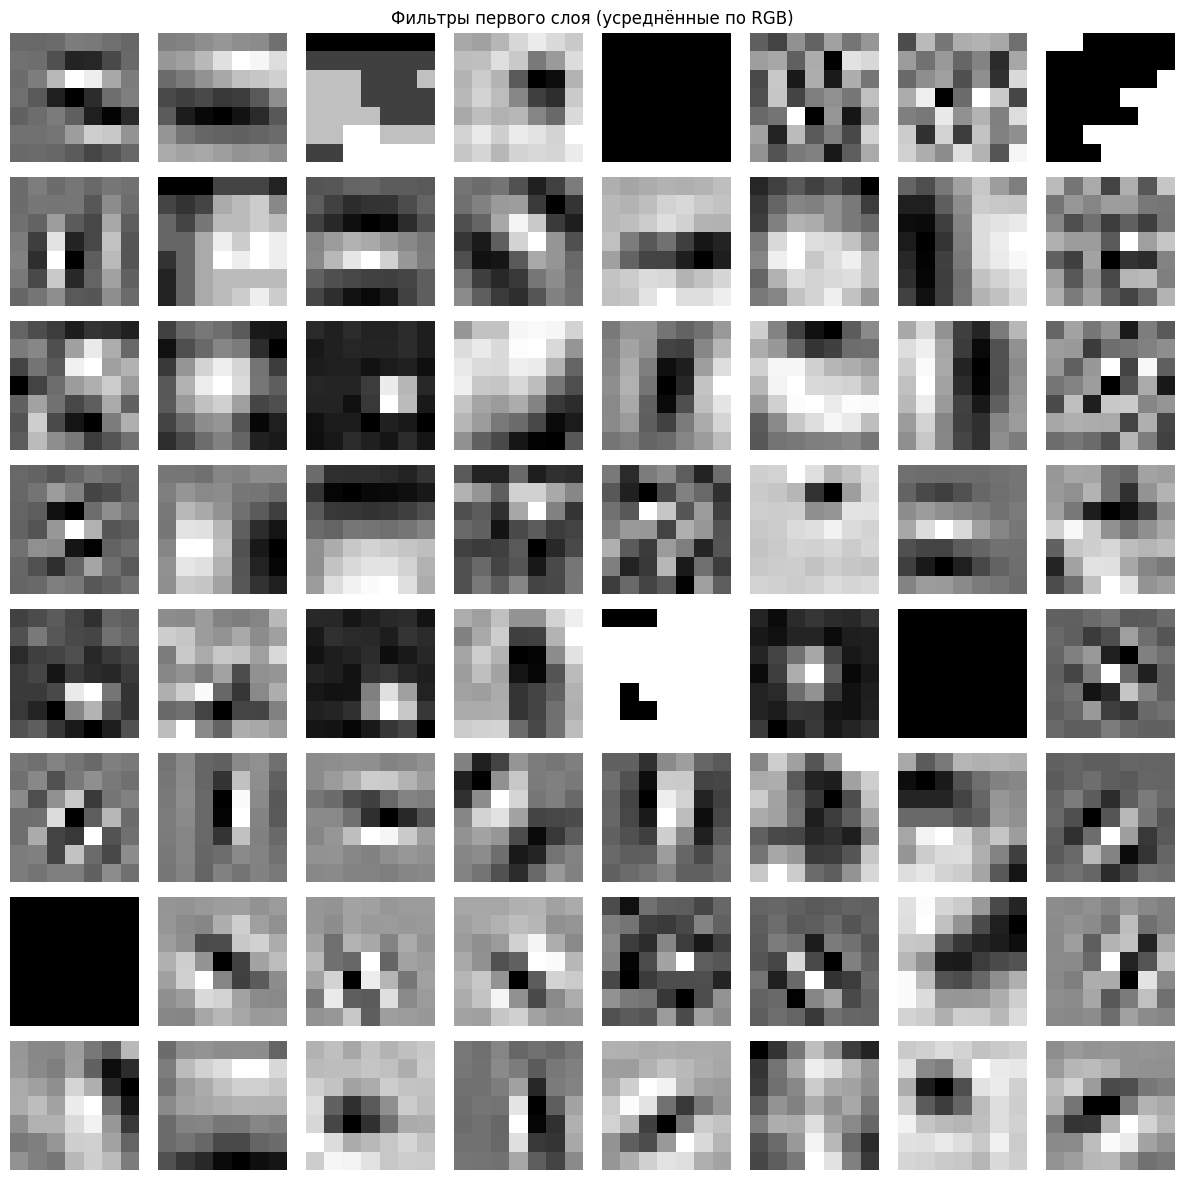

In [12]:
filters = best_model.conv1.weight.detach().cpu()
filters_norm = (filters - filters.min()) / (filters.max() - filters.min())

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < 64:
        # Усреднение по RGB каналам
        ax.imshow(filters_norm[i].mean(0).numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle("Фильтры первого слоя (усреднённые по RGB)")
plt.tight_layout()
plt.show()

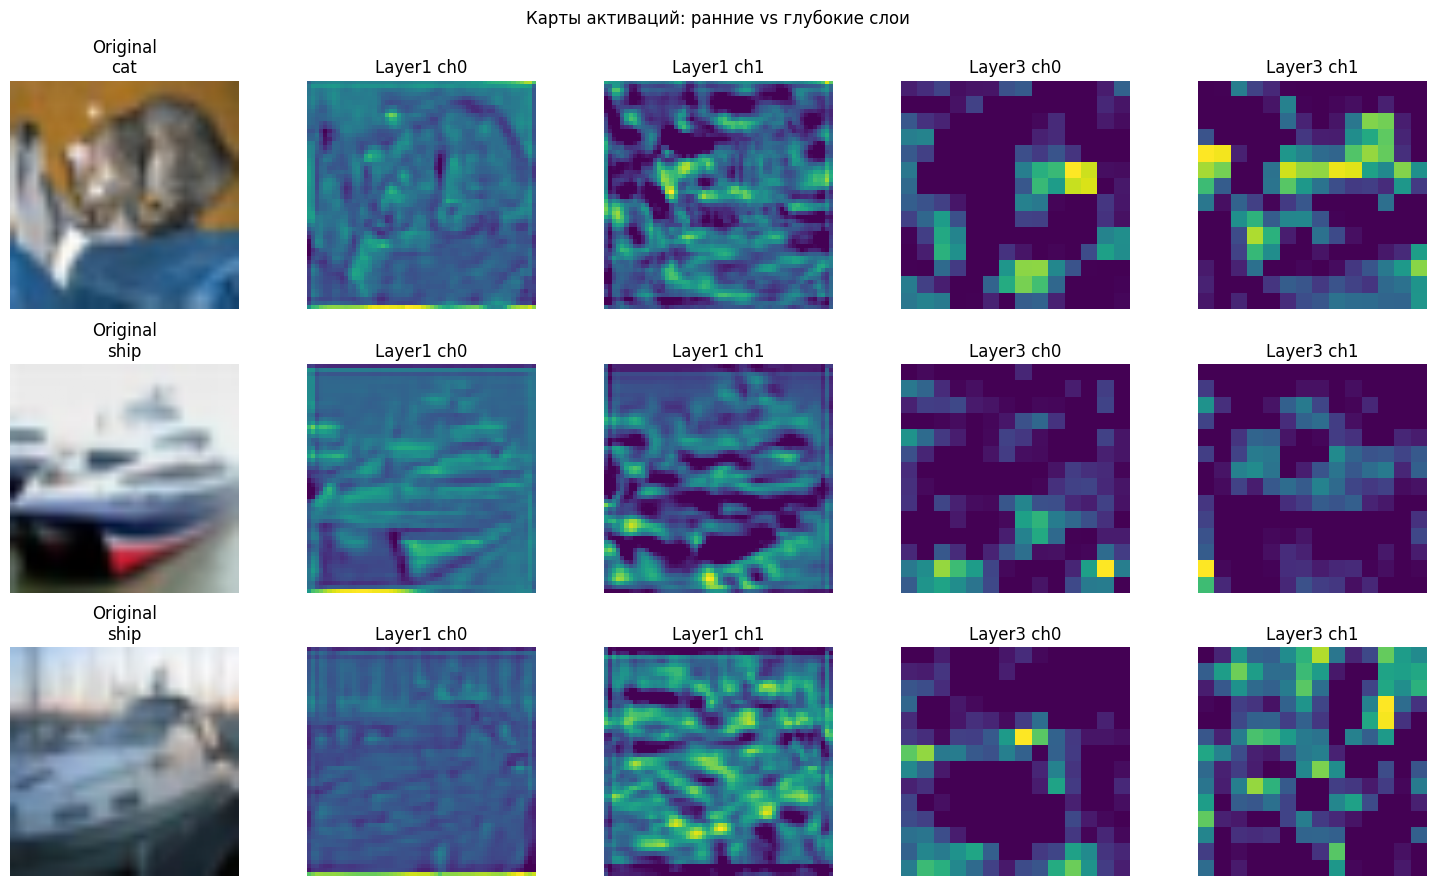

In [13]:
# Регистрируем hooks для извлечения активаций
activations = {}
def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

best_model.layer1.register_forward_hook(hook_fn('layer1'))
best_model.layer3.register_forward_hook(hook_fn('layer3'))

# Получаем изображения
images, labels = next(iter(testloader_bc))
images = images[:3].to(device)

with torch.no_grad():
    best_model(images)

# Визуализация
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i in range(3):
    # Денормализация для отображения
    img = images[i].cpu()
    for c, m, s in zip(img, imagenet_mean, imagenet_std):
        c.mul_(s).add_(m)
    img = torch.clamp(img, 0, 1)
    
    axes[i, 0].imshow(img.permute(1, 2, 0))
    axes[i, 0].set_title(f"Original\n{classes[labels[i]]}")
    
    # Активации layer1 (ранние слои)
    for j in range(2):
        act = activations['layer1'][i, j].cpu()
        act = (act - act.min()) / (act.max() - act.min())
        axes[i, j+1].imshow(act, cmap='viridis')
        axes[i, j+1].set_title(f"Layer1 ch{j}")
    
    # Активации layer3 (глубокие слои)
    for j in range(2):
        act = activations['layer3'][i, j].cpu()
        act = (act - act.min()) / (act.max() - act.min())
        axes[i, j+3].imshow(act, cmap='viridis')
        axes[i, j+3].set_title(f"Layer3 ch{j}")
    
    for ax in axes[i]:
        ax.axis('off')

plt.suptitle("Карты активаций: ранние vs глубокие слои")
plt.tight_layout()
plt.show()

In [48]:
# Полностью удаляем старые определения и создаём новый правильный класс
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def generate(self, image, target_class=None):
        self.model.eval()
        output = self.model(image.unsqueeze(0))
        
        if target_class is None:
            target_class = output.argmax().item()
        
        self.model.zero_grad()
        output[0, target_class].backward()
        
        # Global Average Pooling градиентов
        weights = self.gradients[0].mean(dim=(1, 2), keepdim=True)
        cam = (weights * self.activations[0]).sum(dim=0)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        
        # КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ
        return cam.detach().cpu().numpy(), target_class

In [49]:
# Создаём Grad-CAM для последнего свёрточного слоя
grad_cam = GradCAM(best_model, best_model.layer4[-1])
print("Grad-CAM создан успешно!")

Grad-CAM создан успешно!


In [50]:
# Тест Grad-CAM
test_img = next(iter(testloader_bc))[0][0].to(device)
test_cam, test_class = grad_cam.generate(test_img)
print(f"✅ Grad-CAM работает!")
print(f"Тип: {type(test_cam)}")
print(f"Форма: {test_cam.shape}")
print(f"Минимум: {test_cam.min():.4f}")
print(f"Максимум: {test_cam.max():.4f}")

✅ Grad-CAM работает!
Тип: <class 'numpy.ndarray'>
Форма: (7, 7)
Минимум: 0.0000
Максимум: 1.0000



Ошибка 1: cat → dog (56 случаев)


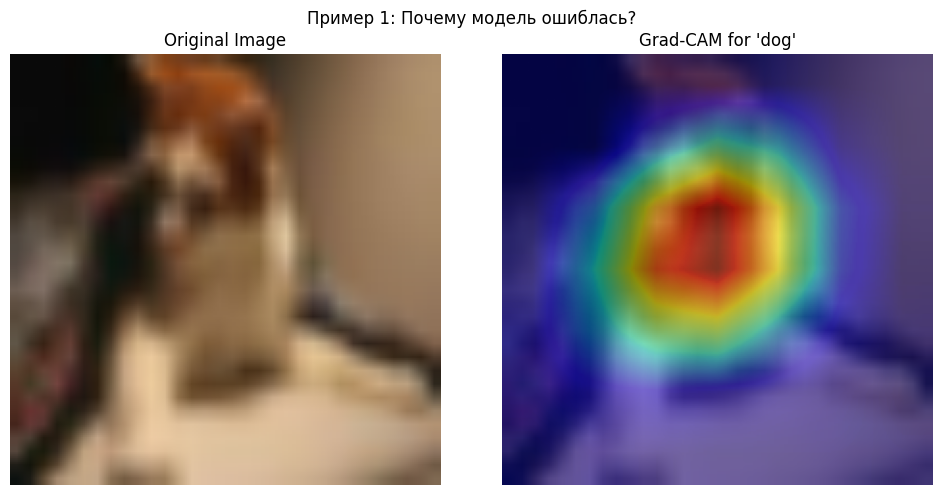


Пример 1:
  - Модель предсказала: dog
  - Истинный класс: cat
  - Область внимания (красная зона): показывает, на что 'смотрела' модель
  - Сложность: Похожие классы (кошки vs собаки)


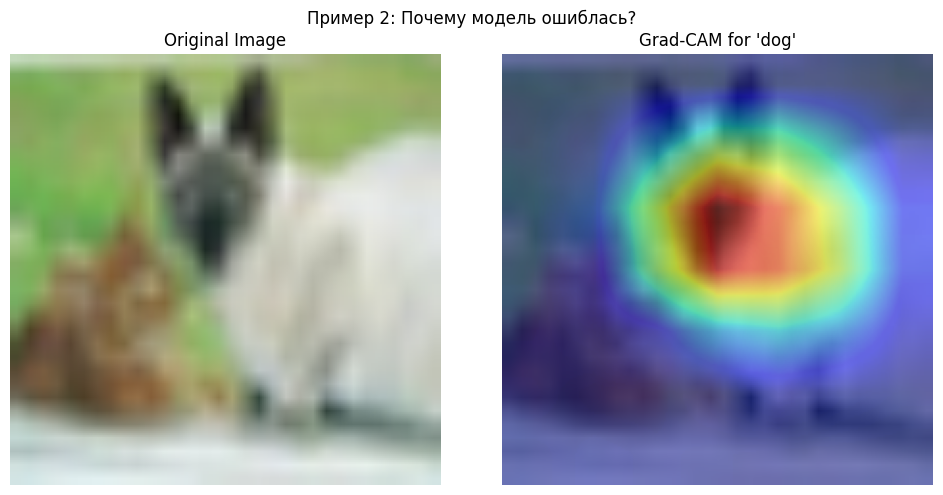


Пример 2:
  - Модель предсказала: dog
  - Истинный класс: cat
  - Область внимания (красная зона): показывает, на что 'смотрела' модель
  - Сложность: Похожие классы (кошки vs собаки)

Ошибка 2: dog → cat (45 случаев)


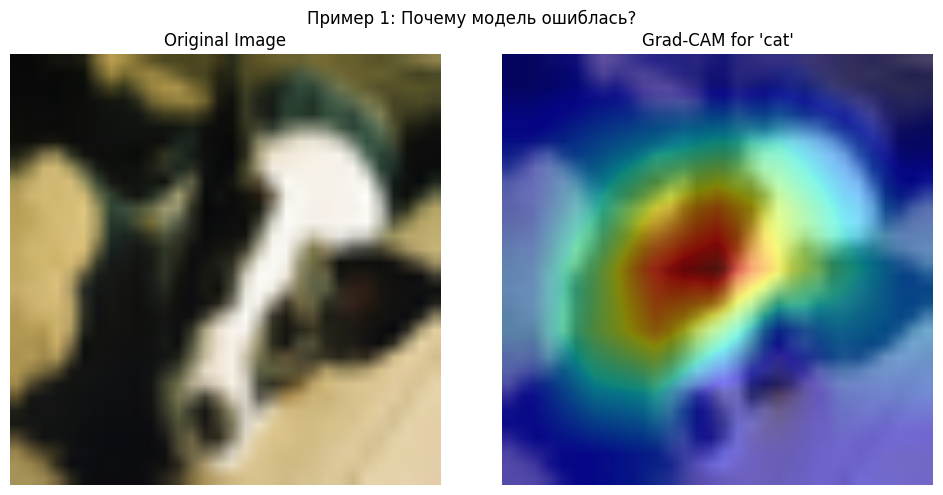


Пример 1:
  - Модель предсказала: cat
  - Истинный класс: dog
  - Область внимания (красная зона): показывает, на что 'смотрела' модель
  - Сложность: Похожие классы (кошки vs собаки)


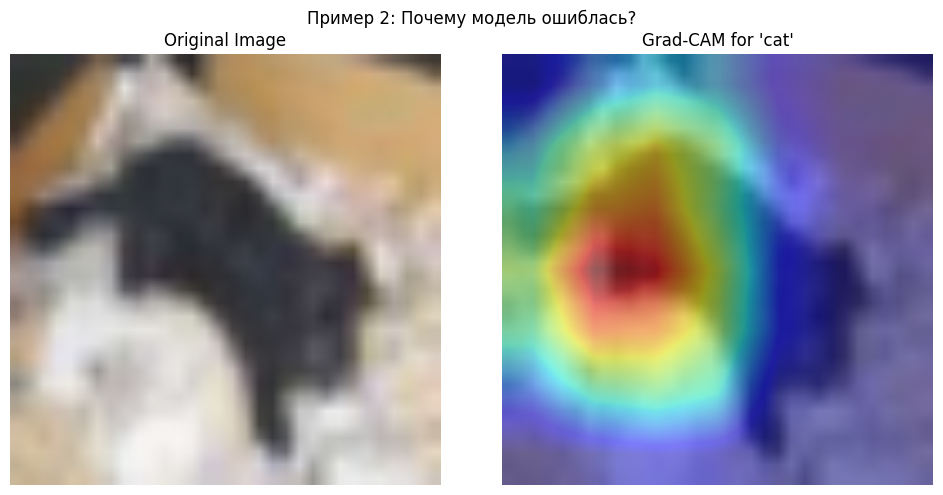


Пример 2:
  - Модель предсказала: cat
  - Истинный класс: dog
  - Область внимания (красная зона): показывает, на что 'смотрела' модель
  - Сложность: Похожие классы (кошки vs собаки)

Ошибка 3: truck → car (26 случаев)


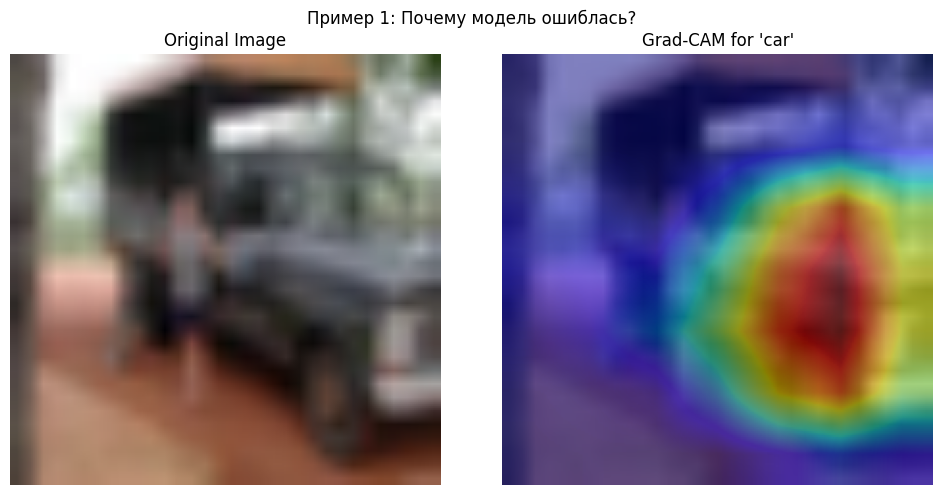


Пример 1:
  - Модель предсказала: car
  - Истинный класс: truck
  - Область внимания (красная зона): показывает, на что 'смотрела' модель
  - Сложность: Транспортные средства


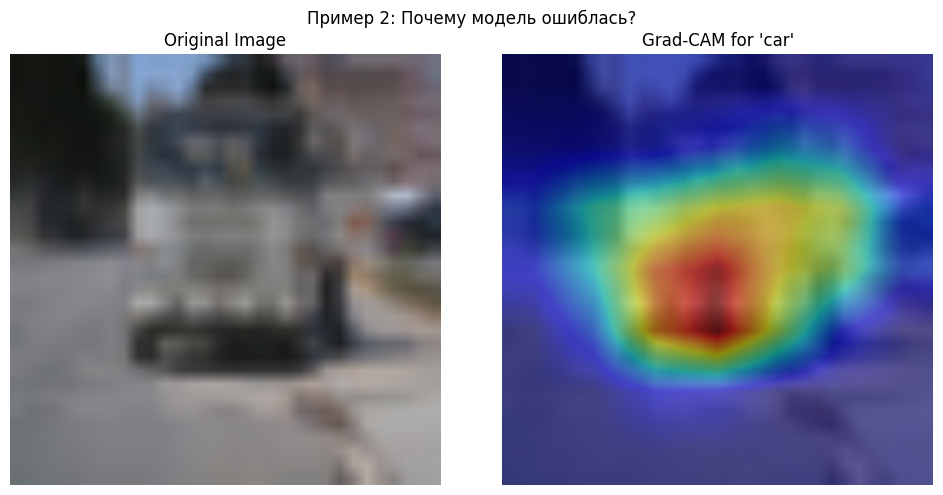


Пример 2:
  - Модель предсказала: car
  - Истинный класс: truck
  - Область внимания (красная зона): показывает, на что 'смотрела' модель
  - Сложность: Транспортные средства


In [51]:
def analyze_error_examples(model, testset, all_labels, all_preds, errors, num_examples=2):
    """
    Анализирует примеры ошибок с Grad-CAM и выводит комментарии
    """
    for err_idx, (true_c, pred_c, count) in enumerate(errors[:3]):
        print(f"\n{'='*50}")
        print(f"Ошибка {err_idx+1}: {classes[true_c]} → {classes[pred_c]} ({count} случаев)")
        print(f"{'='*50}")
        
        # Находим примеры
        mask = (np.array(all_labels) == true_c) & (np.array(all_preds) == pred_c)
        indices = np.where(mask)[0][:num_examples]
        
        for ex_idx, idx in enumerate(indices):
            img_tensor, _ = testset[idx]
            
            # Получаем CAM
            cam, _ = grad_cam.generate(img_tensor.to(device), target_class=pred_c)
            
            # Визуализация
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            
            img_np = img_tensor.numpy().transpose(1, 2, 0)
            for c, m, s in zip(img_np.T, imagenet_mean, imagenet_std):
                c[:] = c * s + m
            img_np = np.clip(img_np, 0, 1)
            
            axes[0].imshow(img_np)
            axes[0].set_title("Original Image")
            axes[0].axis('off')
            
            cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
            axes[1].imshow(img_np)
            axes[1].imshow(cam_resized, cmap='jet', alpha=0.5)
            axes[1].set_title(f"Grad-CAM for '{classes[pred_c]}'")
            axes[1].axis('off')
            
            plt.suptitle(f"Пример {ex_idx+1}: Почему модель ошиблась?")
            plt.tight_layout()
            plt.show()
            
            # Комментарий к ошибке
            print(f"\nПример {ex_idx+1}:")
            print(f"  - Модель предсказала: {classes[pred_c]}")
            print(f"  - Истинный класс: {classes[true_c]}")
            print(f"  - Область внимания (красная зона): показывает, на что 'смотрела' модель")
            
            # Анализ сложности примера
            if classes[true_c] in ['cat', 'dog'] and classes[pred_c] in ['cat', 'dog']:
                print(f"  - Сложность: Похожие классы (кошки vs собаки)")
            elif classes[true_c] in ['deer', 'horse']:
                print(f"  - Сложность: Похожие животные с 4 ногами")
            elif classes[true_c] in ['car', 'truck']:
                print(f"  - Сложность: Транспортные средства")
            else:
                print(f"  - Сложность: Возможно нетипичный ракурс или фон")

# Запускаем анализ
analyze_error_examples(best_model, testset_bc, all_labels, all_preds, errors)

In [52]:
def generate(self, image, target_class=None):
    self.model.eval()
    output = self.model(image.unsqueeze(0))
    
    if target_class is None:
        target_class = output.argmax().item()
    
    self.model.zero_grad()
    output[0, target_class].backward()
    
    # Global Average Pooling градиентов
    weights = self.gradients[0].mean(dim=(1, 2), keepdim=True)
    cam = (weights * self.activations[0]).sum(dim=0)
    cam = F.relu(cam)
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    
    return cam.detach().cpu().numpy(), target_class  

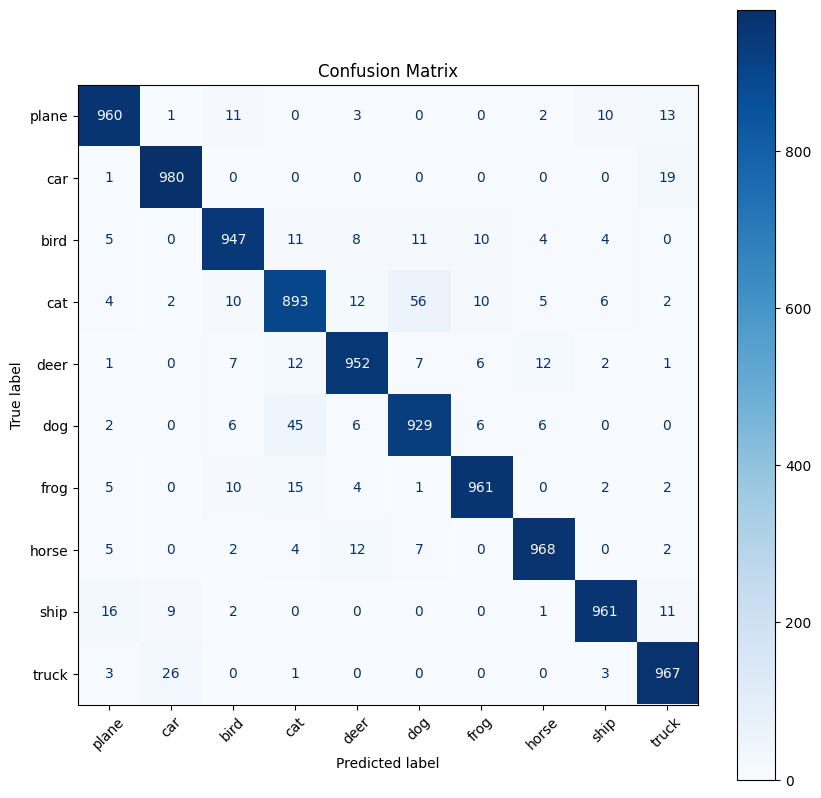

Топ-3 ошибки:
  cat -> dog: 56 случаев
  dog -> cat: 45 случаев
  truck -> car: 26 случаев


In [53]:
# Confusion Matrix
all_preds, all_labels = [], []
best_model.eval()

with torch.no_grad():
    for imgs, lbls in testloader_bc:
        imgs = imgs.to(device)
        preds = best_model(imgs).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Топ-3 ошибки
errors = [(i, j, cm[i, j]) for i in range(10) for j in range(10) if i != j]
errors.sort(key=lambda x: x[2], reverse=True)

print("Топ-3 ошибки:")
for true_c, pred_c, count in errors[:3]:
    print(f"  {classes[true_c]} -> {classes[pred_c]}: {count} случаев")

In [54]:
def generate(self, image, target_class=None):
    self.model.eval()
    output = self.model(image.unsqueeze(0))
    
    if target_class is None:
        target_class = output.argmax().item()
    
    self.model.zero_grad()
    output[0, target_class].backward()
    
    weights = self.gradients[0].mean(dim=(1, 2), keepdim=True)
    cam = (weights * self.activations[0]).sum(dim=0)
    cam = F.relu(cam)
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    
    return cam.detach().cpu().numpy(), target_class 

In [2]:
import torchvision.models as models


best_model = models.resnet18(pretrained=True) 

num_ftrs = best_model.fc.in_features
best_model.fc = nn.Linear(num_ftrs, 10)

best_model.eval()



def visualize_filter_patterns(model):
    # Извлекаем веса первого слоя
    if hasattr(model, 'conv1'):
        filters = model.conv1.weight.detach().cpu()
    else:
        # Для других архитектур, если conv1 называется иначе
        filters = list(model.parameters())[0].detach().cpu()

    # ИСПРАВЛЕНИЕ: Делаем сетку 1 на 4 (ровно под количество категорий)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    patterns = {
        'Горизонтальные границы': [],
        'Вертикальные границы': [],
        'Диагональные / Градиенты': [],
        'Цветовые пятна': []
    }
    
    # Распределяем фильтры
    for i in range(filters.shape[0]):
        filt = filters[i].mean(0).numpy()
        h_grad = np.abs(filt[:, 1:] - filt[:, :-1]).mean()
        v_grad = np.abs(filt[1:, :] - filt[:-1, :]).mean()
        
        if h_grad > v_grad * 1.3:
            patterns['Горизонтальные границы'].append(i)
        elif v_grad > h_grad * 1.3:
            patterns['Вертикальные границы'].append(i)
        elif np.std(filt) < 0.1:
            patterns['Цветовые пятна'].append(i)
        else:
            patterns['Диагональные / Градиенты'].append(i)
    
    # Отрисовка
    for idx, (pattern_name, filter_indices) in enumerate(patterns.items()):
        ax = axes[idx]
        if len(filter_indices) > 0:
            ax.set_title(f"{pattern_name}\n({len(filter_indices)} шт.)")
            sub_filters = filters[filter_indices[:16]]
            grid = torchvision.utils.make_grid(
                sub_filters.mean(1, keepdim=True), 
                nrow=4, normalize=True, padding=2
            )
            ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
        
        ax.axis('off') # Скрываем оси в любом случае
    
    plt.suptitle("Анализ паттернов первого слоя (Исправленная визуализация)", fontsize=16)
    plt.tight_layout()
    plt.show()

# ВЫЗОВ
visualize_filter_patterns(best_model)

ModuleNotFoundError: No module named 'torchvision'